# Ohuseire.ee andmete uurimiseks

Vaatluse all on ohuseire.ee APIst saadud andmed:
- `stations.json`
- `indicators.json`

Eesmärk on näha:
- millised jaamad on olemas,
- kus need asuvad,
- milliseid indikaatoreid mõõdetakse,
- millised näitajad võiksid sobida võrdluseks Open-Meteo andmetega.

In [1]:
import json
import ast
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [4]:
base = Path.cwd().parent

stations_csv = base / "data" / "processed" / "ohuseire" / "stations.csv"
indicators_csv = base / "data" / "processed" / "ohuseire" / "indicators.csv"

stations = pd.read_csv(stations_csv)
indicators = pd.read_csv(indicators_csv)


print(stations.shape)
print(indicators.shape)

(17, 10)
(46, 6)


In [6]:
stations.head(10)

,id,type,geometry.coordinates,geometry.type,properties.type,properties.name,properties.description,properties.image,properties.airviro_code,properties.indicators
0,3,Feature,"[25.928164, 59.515308]",Point,BACKGROUND,Lahemaa,<p>Lahemaa seirejaam paikneb Palmse m&otilde;i...,NaN,S04,"[1, 3, 4, 6, 13, 23, 34, 37, 41]"
1,9,Feature,"[21.844596, 58.376235]",Point,BACKGROUND,Vilsandi,<p>Vilsandi seirejaam paikneb Saaremaast l&aum...,images/stations/vilsandi.jpg,S09,"[1, 3, 6, 23, 34, 37, 41, 81, 82]"
2,10,Feature,"[26.503401, 58.727153]",Point,BACKGROUND,Saarejärve,<p>Saarej&auml;rve seirejaam paikneb J&otilde;...,NaN,S08,"[1, 3, 6, 23, 34, 37, 41]"
3,33,Feature,"[24.925486, 58.52445]",Point,BACKGROUND,Tahkuse,<p>Tahkuse seirejaam paikneb Soomaal alates 19...,NaN,S31,"[1, 3, 6, 11, 68, 69]"
4,11,Feature,"[24.931303, 59.493664]",Point,INDUSTRY,Muuga 1,<p>Muuga 1 seirejaam on paigaldatud Muuga Sada...,NaN,S11,"[8, 11, 34, 37, 41]"
5,16,Feature,"[24.066607, 59.343843]",Point,INDUSTRY,Paldiski,<p>Paldiski seirejaam asub Pakri poolsaarel Al...,images/stations/paldiski.jpg,S23,"[8, 14, 16, 18, 34, 37, 41]"
6,21,Feature,"[27.750225, 59.40276]",Point,INDUSTRY,Sillamäe,<p>Sillam&auml;e seirejaam on paigaldatud Sill...,images/stations/sillamae.jpg,S30,"[8, 10, 11, 14, 16, 18, 20, 21, 23, 34, 37, 41]"
7,38,Feature,"[27.870776, 59.375311]",Point,INDUSTRY,Sinimäe,<p>Sinim&auml;e seirejaam paikneb Sinim&auml;e...,NaN,S32,"[1, 8, 11, 21, 23, 31, 34, 37, 41]"
8,40,Feature,"[27.244931, 59.393961]",Point,INDUSTRY,VKG,<p>VKG seirejaam paikneb VKG tootmisterritoori...,NaN,S18,"[1, 11, 34, 37, 41]"
9,41,Feature,"[27.748683, 59.39384]",Point,INDUSTRY,Sillamäe 2,<p>Sillam&auml;e seirejaam on paigaldatud Sill...,NaN,S33,"[10, 34, 37, 41]"


In [7]:
indicators.head(10)

,id,name,formula,unit,description,levels
0,1,Vääveldioksiid,SO<sub>2</sub>,µg/m3,Vääveldioksiid eraldub välisõhku valdavalt vää...,"[{'id': 5, 'code': 'LEVEL_5', 'name': 'Väga ha..."
1,3,Lämmastikdioksiid,NO<sub>2</sub>,µg/m3,Välisõhku satub lämmastikdioksiid põlemisprots...,"[{'id': 5, 'code': 'LEVEL_5', 'name': 'Väga ha..."
2,4,Süsinikoksiid,CO,mg/m3,Süsinikoksiid ehk vingugaas tekib süsinikku si...,"[{'id': 5, 'code': 'LEVEL_5', 'name': 'Väga ha..."
3,6,Osoon,O<sub>3</sub>,µg/m3,Maapinnalähedane (troposfääri) osoon moodustub...,"[{'id': 5, 'code': 'LEVEL_5', 'name': 'Väga ha..."
4,8,Lenduvad orgaanilised ühendid,NMHC,µg/m3,Lenduvad orgaanilised ühendid ehk LOÜ (volatil...,"[{'id': 5, 'code': 'LEVEL_5', 'name': 'Väga ha..."
5,10,Ammoniaak,NH<sub>3</sub>,ug/m3,"Ammoniaak on terava ja ärritava lõhnaga gaas, ...","[{'id': 5, 'code': 'LEVEL_5', 'name': 'Väga ha..."
6,11,Vesiniksulfiid,H<sub>2</sub>S,ug/m3,Vesiniksulfiid on ebameeldiva lõhnaga (mädamun...,"[{'id': 5, 'code': 'LEVEL_5', 'name': 'Väga ha..."
7,13,Elavhõbe,Hg,ng/m3,Elavhõbe esineb välisõhus gaasilisel kujul. El...,"[{'id': 5, 'code': 'LEVEL_5', 'name': 'Väga ha..."
8,14,Benseen,C<sub>6</sub>H<sub>6</sub>,µg/m3,Benseen on lihtsaima struktuuriga aromaatne sü...,"[{'id': 5, 'code': 'LEVEL_5', 'name': 'Väga ha..."
9,16,Tolueen,C<sub>7</sub>H<sub>8</sub>,µg/m3,NaN,"[{'id': 5, 'code': 'LEVEL_5', 'name': 'Väga ha..."


In [8]:
stations.columns.tolist()

['id',
 'type',
 'geometry.coordinates',
 'geometry.type',
 'properties.type',
 'properties.name',
 'properties.description',
 'properties.image',
 'properties.airviro_code',
 'properties.indicators']

In [9]:
indicators.columns.tolist()

['id', 'name', 'formula', 'unit', 'description', 'levels']

In [10]:
stations.info()

<class 'pandas.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   id                       17 non-null     int64
 1   type                     17 non-null     str  
 2   geometry.coordinates     17 non-null     str  
 3   geometry.type            17 non-null     str  
 4   properties.type          17 non-null     str  
 5   properties.name          17 non-null     str  
 6   properties.description   17 non-null     str  
 7   properties.image         7 non-null      str  
 8   properties.airviro_code  17 non-null     str  
 9   properties.indicators    17 non-null     str  
dtypes: int64(1), str(9)
memory usage: 1.5 KB


In [11]:
indicators.info()

<class 'pandas.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   id           46 non-null     int64
 1   name         46 non-null     str  
 2   formula      46 non-null     str  
 3   unit         46 non-null     str  
 4   description  37 non-null     str  
 5   levels       25 non-null     str  
dtypes: int64(1), str(5)
memory usage: 2.3 KB


Palju jaamu on tüübi järgi:

In [12]:
stations["properties.type"].value_counts()

properties.type
INDUSTRY      7
URBAN         6
BACKGROUND    4
Name: count, dtype: int64


Mitu erinevvat indikaatorit on?

In [13]:
print("Indikaatoreid kokku:", indicators["id"].nunique())

Indikaatoreid kokku: 46


In [16]:
indicators[["id", "name", "formula", "unit"]].head(47)

,id,name,formula,unit
0,1,Vääveldioksiid,SO<sub>2</sub>,µg/m3
1,3,Lämmastikdioksiid,NO<sub>2</sub>,µg/m3
2,4,Süsinikoksiid,CO,mg/m3
3,6,Osoon,O<sub>3</sub>,µg/m3
4,8,Lenduvad orgaanilised ühendid,NMHC,µg/m3
5,10,Ammoniaak,NH<sub>3</sub>,ug/m3
6,11,Vesiniksulfiid,H<sub>2</sub>S,ug/m3
7,13,Elavhõbe,Hg,ng/m3
8,14,Benseen,C<sub>6</sub>H<sub>6</sub>,µg/m3
9,16,Tolueen,C<sub>7</sub>H<sub>8</sub>,µg/m3


lihtsam tabel vaatamiseks:

In [17]:
stations_simple = stations[[
    "id",
    "properties.name",
    "properties.type",
    "geometry.coordinates",
    "properties.airviro_code",
    "properties.indicators"
]].copy()

stations_simple.columns = [
    "station_id",
    "station_name",
    "station_type",
    "coordinates",
    "airviro_code",
    "indicator_ids"
]

stations_simple.head(10)

,station_id,station_name,station_type,coordinates,airviro_code,indicator_ids
0,3,Lahemaa,BACKGROUND,"[25.928164, 59.515308]",S04,"[1, 3, 4, 6, 13, 23, 34, 37, 41]"
1,9,Vilsandi,BACKGROUND,"[21.844596, 58.376235]",S09,"[1, 3, 6, 23, 34, 37, 41, 81, 82]"
2,10,Saarejärve,BACKGROUND,"[26.503401, 58.727153]",S08,"[1, 3, 6, 23, 34, 37, 41]"
3,33,Tahkuse,BACKGROUND,"[24.925486, 58.52445]",S31,"[1, 3, 6, 11, 68, 69]"
4,11,Muuga 1,INDUSTRY,"[24.931303, 59.493664]",S11,"[8, 11, 34, 37, 41]"
5,16,Paldiski,INDUSTRY,"[24.066607, 59.343843]",S23,"[8, 14, 16, 18, 34, 37, 41]"
6,21,Sillamäe,INDUSTRY,"[27.750225, 59.40276]",S30,"[8, 10, 11, 14, 16, 18, 20, 21, 23, 34, 37, 41]"
7,38,Sinimäe,INDUSTRY,"[27.870776, 59.375311]",S32,"[1, 8, 11, 21, 23, 31, 34, 37, 41]"
8,40,VKG,INDUSTRY,"[27.244931, 59.393961]",S18,"[1, 11, 34, 37, 41]"
9,41,Sillamäe 2,INDUSTRY,"[27.748683, 59.39384]",S33,"[10, 34, 37, 41]"


In [19]:
stations_simple["coordinates"].head(20)

0     [25.928164, 59.515308]
1     [21.844596, 58.376235]
2     [26.503401, 58.727153]
3      [24.925486, 58.52445]
4     [24.931303, 59.493664]
5     [24.066607, 59.343843]
6      [27.750225, 59.40276]
7     [27.870776, 59.375311]
8     [27.244931, 59.393961]
9      [27.748683, 59.39384]
10     [26.96529, 59.355848]
11    [27.278662, 59.409624]
12    [28.200689, 59.372201]
13    [24.760456, 59.430989]
14     [24.72192, 59.445146]
15    [24.649744, 59.414041]
16    [26.734845, 58.370587]
Name: coordinates, dtype: str

koordinaadid listiks:

In [20]:
import ast

stations_simple["coordinates_list"] = stations_simple["coordinates"].apply(ast.literal_eval)
stations_simple[["station_name", "coordinates", "coordinates_list"]].head()

,station_name,coordinates,coordinates_list
0,Lahemaa,"[25.928164, 59.515308]","[25.928164, 59.515308]"
1,Vilsandi,"[21.844596, 58.376235]","[21.844596, 58.376235]"
2,Saarejärve,"[26.503401, 58.727153]","[26.503401, 58.727153]"
3,Tahkuse,"[24.925486, 58.52445]","[24.925486, 58.52445]"
4,Muuga 1,"[24.931303, 59.493664]","[24.931303, 59.493664]"


In [22]:
stations_simple["lon"] = stations_simple["coordinates_list"].apply(lambda x: x[0] if isinstance(x, list) and len(x) == 2 else None)
stations_simple["lat"] = stations_simple["coordinates_list"].apply(lambda x: x[1] if isinstance(x, list) and len(x) == 2 else None)

stations_simple[["station_name", "station_type", "lat", "lon"]].head(20)

,station_name,station_type,lat,lon
0,Lahemaa,BACKGROUND,59.515308,25.928164
1,Vilsandi,BACKGROUND,58.376235,21.844596
2,Saarejärve,BACKGROUND,58.727153,26.503401
3,Tahkuse,BACKGROUND,58.524450,24.925486
4,Muuga 1,INDUSTRY,59.493664,24.931303
5,Paldiski,INDUSTRY,59.343843,24.066607
6,Sillamäe,INDUSTRY,59.402760,27.750225
7,Sinimäe,INDUSTRY,59.375311,27.870776
8,VKG,INDUSTRY,59.393961,27.244931
9,Sillamäe 2,INDUSTRY,59.393840,27.748683


In [23]:
stations_simple[["station_id", "station_name", "station_type", "lat", "lon", "airviro_code"]].sort_values("station_name")

,station_id,station_name,station_type,lat,lon,airviro_code
10,44,Kiviõli,INDUSTRY,59.355848,26.965290,S34
11,1,Kohtla-Järve,URBAN,59.409624,27.278662,S03
0,3,Lahemaa,BACKGROUND,59.515308,25.928164,S04
13,5,Liivalaia,URBAN,59.430989,24.760456,S00
4,11,Muuga 1,INDUSTRY,59.493664,24.931303,S11
12,4,Narva,URBAN,59.372201,28.200689,S25
5,16,Paldiski,INDUSTRY,59.343843,24.066607,S23
14,6,Rahu,URBAN,59.445146,24.721920,S01
2,10,Saarejärve,BACKGROUND,58.727153,26.503401,S08
6,21,Sillamäe,INDUSTRY,59.402760,27.750225,S30


In [ ]:
import requests
import pandas as pd
from datetime import datetime

BASE = "https://www.ohuseire.ee/api"
LOCALE = "et"

r = requests.get(
    f"{BASE}/station/{LOCALE}",
    params={"type": "INDICATOR"},
    timeout=30
)
r.raise_for_status()

stations_raw = r.json()
stations_df = pd.json_normalize(stations_raw["features"])

def parse_indicator_ids(x):
    if x is None:
        return []
    if isinstance(x, list):
        return [int(i) for i in x]
    if isinstance(x, tuple):
        return [int(i) for i in x]
    s = str(x).strip()
    if s == "" or s.lower() == "nan":
        return []
    return [int(i.strip()) for i in s.split(",") if i.strip()]

stations_df["indicator_ids"] = stations_df["properties.indicators"].apply(parse_indicator_ids)

stations_df = stations_df[[
    "id",
    "properties.name",
    "properties.type",
    "properties.airviro_code",
    "indicator_ids"
]].rename(columns={
    "id": "station_id",
    "properties.name": "station_name",
    "properties.type": "station_type",
    "properties.airviro_code": "airviro_code"
})

stations_df.head()

,station_id,station_name,station_type,airviro_code,indicator_ids
0,3,Lahemaa,BACKGROUND,S04,"[1, 3, 4, 6, 13, 23, 34, 37, 41]"
1,9,Vilsandi,BACKGROUND,S09,"[1, 3, 6, 23, 34, 37, 41, 81, 82]"
2,10,Saarejärve,BACKGROUND,S08,"[1, 3, 6, 23, 34, 37, 41]"
3,33,Tahkuse,BACKGROUND,S31,"[1, 3, 6, 11, 68, 69]"
4,11,Muuga 1,INDUSTRY,S11,"[8, 11, 34, 37, 41]"


Mõõteandmed test

In [32]:
today = datetime.now()
range_str = f"{today.strftime('%d.%m.%Y')},{today.strftime('%d.%m.%Y')}"

rows = []

for _, row in stations_df.iterrows():
    station_id = int(row["station_id"])

    for indicator_id in row["indicator_ids"]:
        params = {
            "type": "INDICATOR",
            "stations": str(station_id),
            "indicators": str(indicator_id),
            "range": range_str
        }

        try:
            r = requests.get(f"{BASE}/monitoring/{LOCALE}", params=params, timeout=30)

            if r.status_code == 200:
                data = r.json()
                for item in data:
                    rows.append({
                        "station_id": station_id,
                        "station_name": row["station_name"],
                        "station_type": row["station_type"],
                        "airviro_code": row["airviro_code"],
                        "indicator_id": item.get("indicator"),
                        "measured": item.get("measured"),
                        "value": item.get("value"),
                        "monitoring_id": item.get("id")
                    })
            else:
                rows.append({
                    "station_id": station_id,
                    "station_name": row["station_name"],
                    "station_type": row["station_type"],
                    "airviro_code": row["airviro_code"],
                    "indicator_id": indicator_id,
                    "measured": None,
                    "value": None,
                    "monitoring_id": None,
                    "error_status": r.status_code
                })

        except Exception as e:
            rows.append({
                "station_id": station_id,
                "station_name": row["station_name"],
                "station_type": row["station_type"],
                "airviro_code": row["airviro_code"],
                "indicator_id": indicator_id,
                "measured": None,
                "value": None,
                "monitoring_id": None,
                "error_status": str(e)
            })

monitoring_df = pd.DataFrame(rows)

monitoring_df["measured"] = pd.to_datetime(monitoring_df["measured"], errors="coerce")
monitoring_df["value"] = pd.to_numeric(monitoring_df["value"], errors="coerce")

monitoring_df.head()

,station_id,station_name,station_type,airviro_code,indicator_id,measured,value,monitoring_id
0,3,Lahemaa,BACKGROUND,S04,1,2026-05-27 01:00:00,0.2,34508503
1,3,Lahemaa,BACKGROUND,S04,1,2026-05-27 02:00:00,0.2,34508639
2,3,Lahemaa,BACKGROUND,S04,1,2026-05-27 03:00:00,0.2,34508776
3,3,Lahemaa,BACKGROUND,S04,1,2026-05-27 04:00:00,0.2,34508922
4,3,Lahemaa,BACKGROUND,S04,1,2026-05-27 05:00:00,0.2,34509052


viimane tund(jooksutasin 15:16):

In [33]:
last_ts = monitoring_df["measured"].max()
last_hour_df = monitoring_df[monitoring_df["measured"] == last_ts].copy()

print("Viimane ajatempel:", last_ts)
last_hour_df.head(20)

Viimane ajatempel: 2026-05-27 15:00:00


,station_id,station_name,station_type,airviro_code,indicator_id,measured,value,monitoring_id
14,3,Lahemaa,BACKGROUND,S04,1,2026-05-27 15:00:00,0.2,34510481
29,3,Lahemaa,BACKGROUND,S04,3,2026-05-27 15:00:00,0.4,34510559
44,3,Lahemaa,BACKGROUND,S04,4,2026-05-27 15:00:00,0.2,34510482
59,3,Lahemaa,BACKGROUND,S04,6,2026-05-27 15:00:00,69.7,34510483
74,3,Lahemaa,BACKGROUND,S04,13,2026-05-27 15:00:00,1.2,34510484
89,3,Lahemaa,BACKGROUND,S04,23,2026-05-27 15:00:00,2.0,34510485
104,3,Lahemaa,BACKGROUND,S04,34,2026-05-27 15:00:00,13.5,34510486
119,3,Lahemaa,BACKGROUND,S04,37,2026-05-27 15:00:00,244.5,34510487
134,3,Lahemaa,BACKGROUND,S04,41,2026-05-27 15:00:00,3.5,34510488
149,9,Vilsandi,BACKGROUND,S09,1,2026-05-27 15:00:00,0.2,34510489


vii info kokku ja näita ühe jaama viimase tunni andmeid:

In [37]:
indicators_lookup = indicators[[
    "id",
    "name",
    "formula",
    "unit",
    "description"
]].rename(columns={"id": "indicator_id"})

def show_station_last_hour(station_selector):
    last_ts = monitoring_df["measured"].max()
    df = monitoring_df[monitoring_df["measured"] == last_ts].copy()

    if isinstance(station_selector, str):
        df = df[df["airviro_code"] == station_selector].copy()
    else:
        df = df[df["station_id"] == int(station_selector)].copy()

    df = df.merge(
        indicators_lookup,
        on="indicator_id",
        how="left"
    )

    df = df[[
        "station_name",
        "airviro_code",
        "station_type",
        "indicator_id",
        "name",
        "formula",
        "unit",
        "description",
        "value",
        "measured",
        "monitoring_id"
    ]].sort_values("indicator_id")

    return df

lahemaa_last = show_station_last_hour("S04")
lahemaa_last

,station_name,airviro_code,station_type,indicator_id,name,formula,unit,description,value,measured,monitoring_id
0,Lahemaa,S04,BACKGROUND,1,Vääveldioksiid,SO<sub>2</sub>,µg/m3,Vääveldioksiid eraldub välisõhku valdavalt vää...,0.2,2026-05-27 15:00:00,34510481
1,Lahemaa,S04,BACKGROUND,3,Lämmastikdioksiid,NO<sub>2</sub>,µg/m3,Välisõhku satub lämmastikdioksiid põlemisprots...,0.4,2026-05-27 15:00:00,34510559
2,Lahemaa,S04,BACKGROUND,4,Süsinikoksiid,CO,mg/m3,Süsinikoksiid ehk vingugaas tekib süsinikku si...,0.2,2026-05-27 15:00:00,34510482
3,Lahemaa,S04,BACKGROUND,6,Osoon,O<sub>3</sub>,µg/m3,Maapinnalähedane (troposfääri) osoon moodustub...,69.7,2026-05-27 15:00:00,34510483
4,Lahemaa,S04,BACKGROUND,13,Elavhõbe,Hg,ng/m3,Elavhõbe esineb välisõhus gaasilisel kujul. El...,1.2,2026-05-27 15:00:00,34510484
5,Lahemaa,S04,BACKGROUND,23,Eriti peened osakesed,PM2.5,µg/m3,Tahked ja vedelad osakesed aerodünaamilise dia...,2.0,2026-05-27 15:00:00,34510485
6,Lahemaa,S04,BACKGROUND,34,Temperatuur,TEMP,deg.C,Õhutemperatuuri mõõdetakse pidevalt varjus ole...,13.5,2026-05-27 15:00:00,34510486
7,Lahemaa,S04,BACKGROUND,37,Tuule suund 10 m kõrgusel,WD<sub>10</sub>,Deg °,"Tuule suund näitab seda horisondi punkti, mill...",244.5,2026-05-27 15:00:00,34510487
8,Lahemaa,S04,BACKGROUND,41,Tuule kiirus 10 m kõrgusel,WS<sub>10</sub>,m/s,Tuule kiirust mõõdetakse ultrahelianemomeetrig...,3.5,2026-05-27 15:00:00,34510488


          id            measured  value  station  indicator
0   34508507 2026-05-27 01:00:00    1.0        3         23
1   34508643 2026-05-27 02:00:00    1.0        3         23
2   34508780 2026-05-27 03:00:00    1.0        3         23
3   34508926 2026-05-27 04:00:00    1.0        3         23
4   34509056 2026-05-27 05:00:00    2.0        3         23
5   34509209 2026-05-27 06:00:00    3.0        3         23
6   34509341 2026-05-27 07:00:00    3.0        3         23
7   34509487 2026-05-27 08:00:00    3.0        3         23
8   34509615 2026-05-27 09:00:00    3.0        3         23
9   34509762 2026-05-27 10:00:00    3.0        3         23
10  34509913 2026-05-27 11:00:00    2.5        3         23
11  34510053 2026-05-27 12:00:00    2.0        3         23
12  34510198 2026-05-27 13:00:00    2.0        3         23
13  34510331 2026-05-27 14:00:00    2.0        3         23
14  34510485 2026-05-27 15:00:00    2.0        3         23
15  34510610 2026-05-27 16:00:00    2.0 

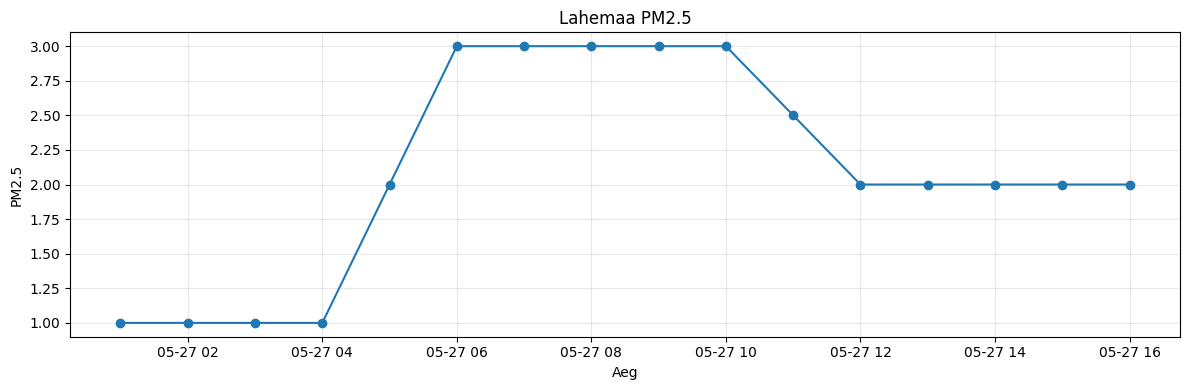

In [44]:

params = {
    "type": "INDICATOR",
    "stations": "3",      # Lahemaa
    "indicators": "23",   # PM2.5
    "range": f"{datetime.now().strftime('%d.%m.%Y')},{datetime.now().strftime('%d.%m.%Y')}",
}

r = requests.get("https://www.ohuseire.ee/api/monitoring/et", params=params, timeout=30)
r.raise_for_status()

df_plot = pd.DataFrame(r.json())
df_plot["measured"] = pd.to_datetime(df_plot["measured"], errors="coerce")
df_plot["value"] = pd.to_numeric(df_plot["value"], errors="coerce")
df_plot = df_plot.dropna(subset=["measured", "value"]).sort_values("measured")

print(df_plot[["id", "measured", "value", "station", "indicator"]])

plt.figure(figsize=(12, 4))
plt.plot(df_plot["measured"], df_plot["value"], marker="o")
plt.title("Lahemaa PM2.5")
plt.xlabel("Aeg")
plt.ylabel("PM2.5")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()